In [1]:
# ─────────────────────────────────────────────
# 모두마켓 웹 접속 로그(가상) — 일부러 오염을 심어 둡니다.
# ─────────────────────────────────────────────
# ===== 기본 세트 (거의 항상 필요) =====
import pandas as pd                    # 데이터프레임 다루기 (표 형태 데이터 처리)
import numpy as np                     # 수치 계산, 배열 연산
import matplotlib.pyplot as plt        # 기본 시각화
import seaborn as sns                  # matplotlib 기반의, 더 예쁘고 간결한 통계 시각화

# ===== 파일/경로/시스템 =====
import os                              # 파일 경로 확인, 파일 존재 여부(os.path.exists) 등
from pathlib import Path               # 폴더/파일 경로를 객체로 다루기 (work_dir / "파일명")
import joblib                          # 학습된 scaler/encoder를 파일로 저장하고 재사용
import platform                        # OS 종류 확인 (Windows/Mac/Linux 구분 필요할 때)
import warnings                        # 경고 메시지 제어(숨기기/표시)

# ===== 벤치마크/성능 측정 =====
import time                            # 코드 실행 시간 측정 (time.perf_counter())
import psutil                          # 메모리 사용량 측정 (rss_mb 등)
import gc                              # 메모리 강제 정리(garbage collection)

# ===== 결측치 탐색 시각화 =====
import missingno as msno               # 결측치 위치(matrix), 관계(heatmap) 시각화

# ===== 인터랙티브 시각화 =====
import plotly.express as px            # 마우스 hover/zoom 가능한 인터랙티브 그래프
import plotly.io as pio                 # plotly 렌더러(출력 방식) 설정

# ===== 대용량 데이터 처리 =====
import polars as pl                     # pandas보다 빠른 대용량 데이터 처리 (Rust 기반)

# ===== 통계 검증 =====
import statsmodels.api as sm            # 회귀분석, 다중공선성(Cond. No.) 등 통계 검증

# ===== 한글 폰트 설정 =====
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# ===== 인코딩/스케일링/모델링 (sklearn) =====
from sklearn.preprocessing import LabelEncoder      # 카테고리를 숫자로 변환 (순서형)
from sklearn.preprocessing import MinMaxScaler       # 0~1 범위로 스케일링
from sklearn.preprocessing import StandardScaler     # 평균0, 표준편차1로 스케일링
from sklearn.preprocessing import RobustScaler       # 이상치에 강한 스케일링 (median/IQR 기반)
from sklearn.linear_model import LinearRegression    # 선형 회귀 모델
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀(분류) 모델
from sklearn.ensemble import RandomForestRegressor   # 랜덤포레스트(트리 기반) 모델
from sklearn.metrics import roc_auc_score, log_loss  # 분류 모델 평가지표

np.random.seed(7)
n_log = 2500
logs_raw = pd.DataFrame({
    "log_id":           [f"L{str(i).zfill(6)}" for i in range(1, n_log + 1)],
    "session_id":       np.random.choice([f"S{str(i).zfill(4)}" for i in range(1, 401)], n_log),
    "response_time_ms": np.abs(np.random.normal(180, 80, n_log)).round(0),
    "request_path":     np.random.choice(["/home", "/category", "/product", "/cart", "/checkout"], n_log,
                                         p=[0.35, 0.2, 0.25, 0.1, 0.1]),
    "device":           np.random.choice(["mobile", "Mobile", "MOBILE", "desktop", "DESKTOP"], n_log,
                                         p=[0.35, 0.15, 0.2, 0.2, 0.1]),
    "hour":             np.random.randint(0, 24, n_log),
    "is_error":         np.random.choice([0, 1], n_log, p=[0.97, 0.03]),
})
# 의도적 오염
# (a) response_time_ms 결측 (심야 시간대에 많이 — 측정 모듈 점검 시간) — MAR 패턴
night = logs_raw["hour"].isin([2, 3, 4])
night_idx = logs_raw[night].sample(min(80, night.sum()), random_state=1).index
day_idx = logs_raw[~night].sample(40, random_state=1).index
logs_raw.loc[night_idx, "response_time_ms"] = np.nan
logs_raw.loc[day_idx, "response_time_ms"] = np.nan
# (b) response_time_ms 이상치 (네트워크 정체로 60초·45초 지연된 응답)
logs_raw.loc[5, "response_time_ms"] = 60_000
logs_raw.loc[6, "response_time_ms"] = 45_000
# (c) hour 이상치 (잘못된 값)
logs_raw.loc[100, "hour"] = 99
# (d) 중복
logs_raw = pd.concat([logs_raw, logs_raw.iloc[[0, 1]]], ignore_index=True)

print("웹 로그 준비:", logs_raw.shape, "| 결측 response_time_ms:", logs_raw["response_time_ms"].isna().sum())
logs_raw.head(3)

웹 로그 준비: (2502, 7) | 결측 response_time_ms: 120


,log_id,session_id,response_time_ms,request_path,device,hour,is_error
0,L000001,S0176,275.0,/home,Mobile,23,0
1,L000002,S0197,217.0,/category,mobile,8,0
2,L000003,S0026,85.0,/home,desktop,6,0


In [2]:
logs_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2502 entries, 0 to 2501
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   log_id            2502 non-null   str    
 1   session_id        2502 non-null   str    
 2   response_time_ms  2382 non-null   float64
 3   request_path      2502 non-null   str    
 4   device            2502 non-null   str    
 5   hour              2502 non-null   int32  
 6   is_error          2502 non-null   int64  
dtypes: float64(1), int32(1), int64(1), str(4)
memory usage: 188.7 KB


In [3]:
def logs_raw_copy(logs_raw):
    logs_raw_clean = logs_raw.copy()
    return logs_raw_clean

logs_raw_clean = logs_raw_copy(logs_raw)

In [4]:
logs_raw_clean.head()

,log_id,session_id,response_time_ms,request_path,device,hour,is_error
0,L000001,S0176,275.0,/home,Mobile,23,0
1,L000002,S0197,217.0,/category,mobile,8,0
2,L000003,S0026,85.0,/home,desktop,6,0
3,L000004,S0068,179.0,/product,DESKTOP,9,0
4,L000005,S0212,210.0,/category,mobile,0,0


In [27]:
logs_raw_clean = logs_raw_clean.drop_duplicates(keep = "first")

In [28]:
duplicates = logs_raw_clean[logs_raw_clean.duplicated(keep=False)]   # 중복된 행들을 전부 보여줌 (원본+복사본 다 포함)
print(duplicates)

Empty DataFrame
Columns: [log_id, session_id, response_time_ms, request_path, device, hour, is_error]
Index: []


In [7]:
def hour_clean(logs_raw_clean):
    logs_raw_clean["hour"] = logs_raw_clean["hour"].where(
        (logs_raw_clean["hour"] >= 0) & (logs_raw_clean["hour"] <= 24), 
        np.nan)
    logs_raw_clean["hour"] = logs_raw_clean["hour"].astype("Int64")
    return logs_raw_clean

logs_raw_clean = hour_clean(logs_raw_clean)

In [8]:
logs_raw_clean["hour"].value_counts(dropna=False)

hour
3       122
0       119
11      114
21      114
16      113
19      113
14      112
22      111
9       110
10      110
5       110
1       109
13      104
8       101
18      100
2        98
6        97
15       97
7        96
17       96
20       94
23       93
12       90
4        76
<NA>      1
Name: count, dtype: Int64

In [9]:
logs_raw_clean["request_path"].value_counts()

request_path
/home        913
/product     620
/category    501
/cart        259
/checkout    207
Name: count, dtype: int64

In [10]:
logs_raw_clean["request_path"] = logs_raw_clean["request_path"].astype("category")

In [11]:
logs_raw_clean["request_path"].dtype

CategoricalDtype(categories=['/cart', '/category', '/checkout', '/home', '/product'], ordered=False, categories_dtype=str)

In [12]:
logs_raw_clean["device"].value_counts()

device
mobile     842
desktop    522
MOBILE     500
Mobile     378
DESKTOP    258
Name: count, dtype: int64

In [13]:
def device_clean(logs_raw_clean):
    logs_raw_clean["device"] = logs_raw_clean["device"].str.lower()
    return logs_raw_clean

logs_raw_clean = device_clean(logs_raw_clean)

In [29]:
logs_raw_clean["device"].value_counts(dropna=False)

device
mobile     1720
desktop     780
Name: count, dtype: int64

In [15]:
logs_raw_clean["device"] = logs_raw_clean["device"].astype("category")

In [16]:
print(logs_raw_clean["device"].dtype)

category


In [17]:
def response_time_ms_clean(logs_raw_clean):
    logs_raw_clean["response_time_ms"] = logs_raw_clean["response_time_ms"].where(
        (logs_raw_clean["response_time_ms"] >= 0) & (logs_raw_clean["response_time_ms"] <= 3_000), 
        np.nan)
    logs_raw_clean["response_time_ms"] = logs_raw_clean["response_time_ms"].astype("Int64")
    return logs_raw_clean

logs_raw_clean = response_time_ms_clean(logs_raw_clean)

In [18]:
logs_raw_clean["response_time_ms"].value_counts(dropna=False).sort_index(ascending=False)

response_time_ms
446       1
422       1
411       1
403       1
400       1
       ... 
3         2
2         3
1         1
0         3
<NA>    122
Name: count, Length: 363, dtype: Int64

In [19]:
print(logs_raw_clean["response_time_ms"].dtype)

Int64


In [20]:
logs_raw_clean["is_error"] = logs_raw_clean["is_error"].astype("int8")
logs_raw_clean["is_error"].value_counts(dropna=False)

is_error
0    2427
1      73
Name: count, dtype: int64

In [21]:
#esponse_time_ms의 결측 비율은 얼마인가요?
esponse_time_ms_NA_ratio = (logs_raw_clean["response_time_ms"].isnull().sum() / len(logs_raw_clean) * 100).round(2)
print(esponse_time_ms_NA_ratio)

4.88


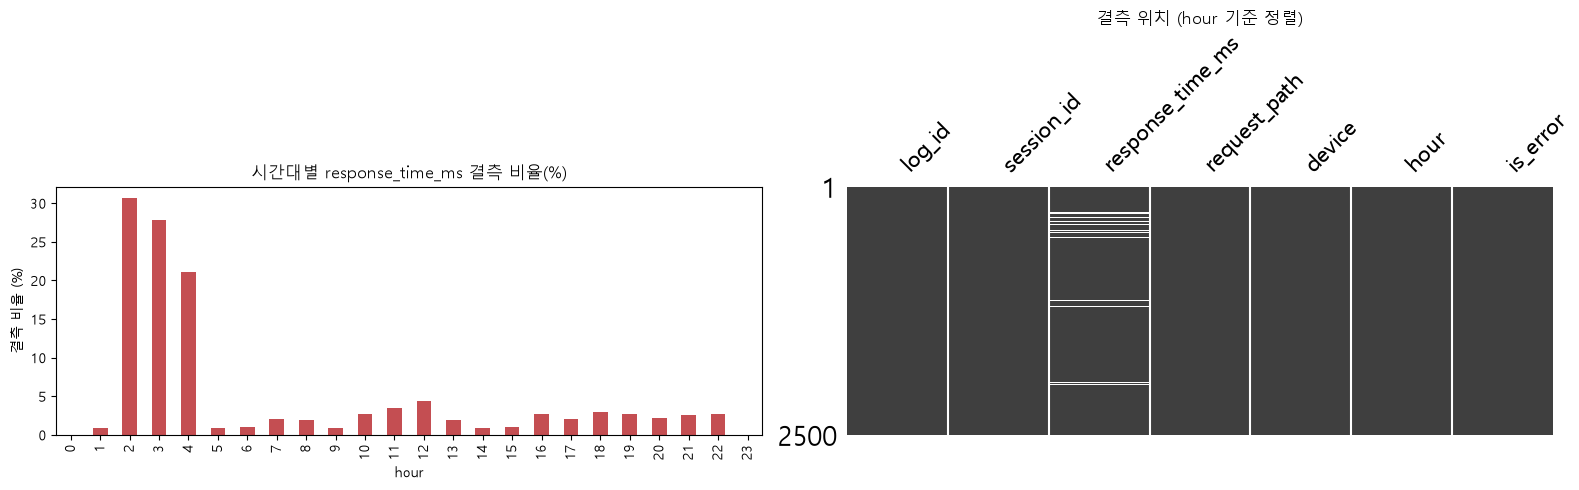

In [22]:
missing_by_hour = logs_raw_clean.groupby("hour")["response_time_ms"].apply(
    lambda x: x.isnull().mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_by_hour.plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("시간대별 response_time_ms 결측 비율(%)")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("결측 비율 (%)")

logs_sorted = logs_raw_clean.sort_values("hour").reset_index(drop=True)
msno.matrix(logs_sorted, ax=axes[1], sparkline=False)
axes[1].set_title("결측 위치 (hour 기준 정렬)")

plt.tight_layout()
plt.show()

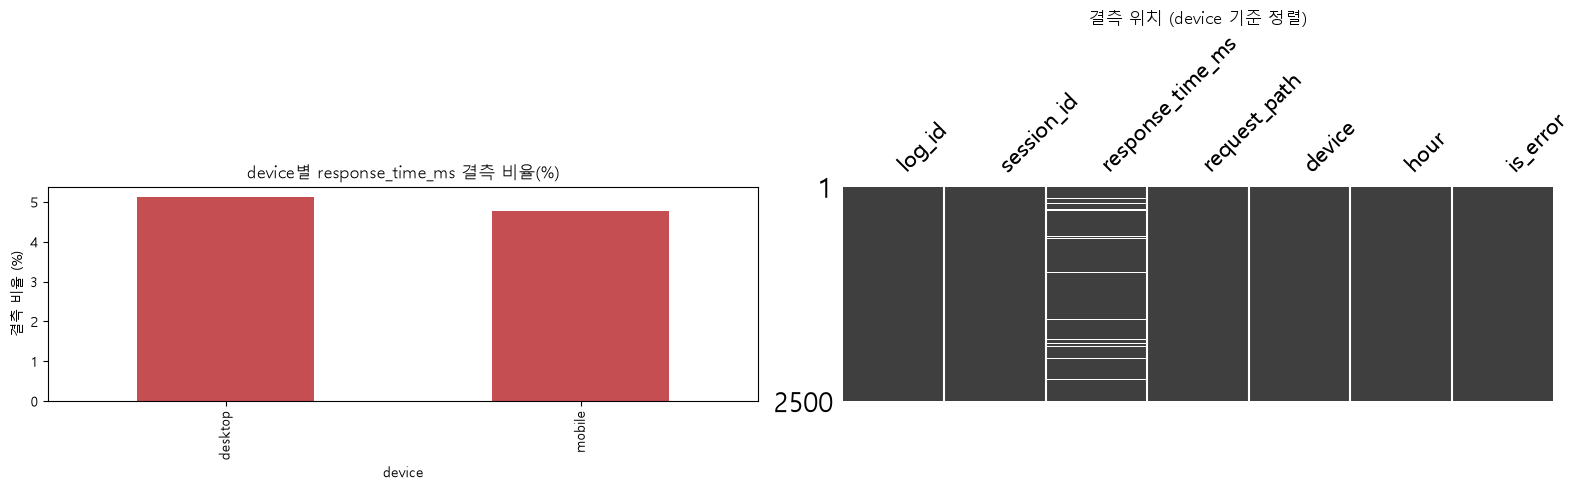

In [31]:
missing_by_hour = logs_raw_clean.groupby("device")["response_time_ms"].apply(
    lambda x: x.isnull().mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_by_hour.plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("device별 response_time_ms 결측 비율(%)")
axes[0].set_xlabel("device")
axes[0].set_ylabel("결측 비율 (%)")

logs_sorted = logs_raw_clean.sort_values("device").reset_index(drop=True)
msno.matrix(logs_sorted, ax=axes[1], sparkline=False)
axes[1].set_title("결측 위치 (device 기준 정렬)")

plt.tight_layout()
plt.show()

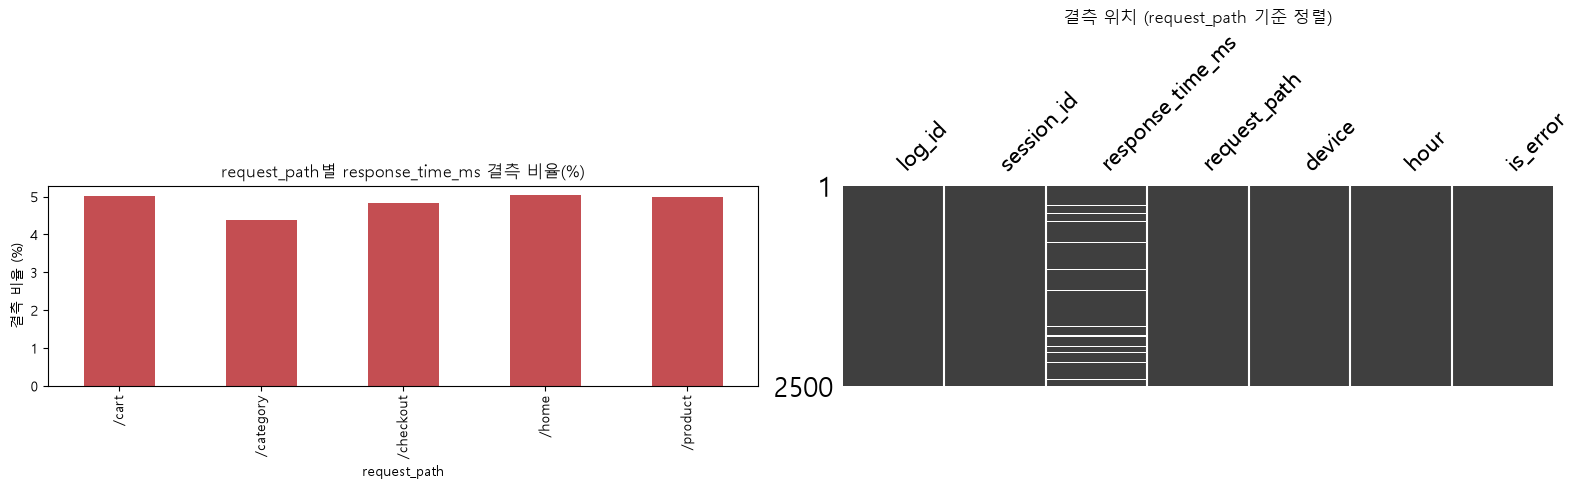

In [32]:
missing_by_hour = logs_raw_clean.groupby("request_path")["response_time_ms"].apply(
    lambda x: x.isnull().mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_by_hour.plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("request_path별 response_time_ms 결측 비율(%)")
axes[0].set_xlabel("request_path")
axes[0].set_ylabel("결측 비율 (%)")

logs_sorted = logs_raw_clean.sort_values("request_path").reset_index(drop=True)
msno.matrix(logs_sorted, ax=axes[1], sparkline=False)
axes[1].set_title("결측 위치 (request_path 기준 정렬)")

plt.tight_layout()
plt.show()

In [30]:
id_counts = logs_raw_clean["log_id"].value_counts()
print(id_counts[id_counts > 1])

session_id_counts = logs_raw_clean["session_id"].value_counts()
print(session_id_counts[session_id_counts > 1])

Series([], Name: count, dtype: int64)
session_id
S0078    14
S0175    14
S0181    13
S0323    13
S0304    13
         ..
S0279     2
S0051     2
S0054     2
S0229     2
S0099     2
Name: count, Length: 392, dtype: int64


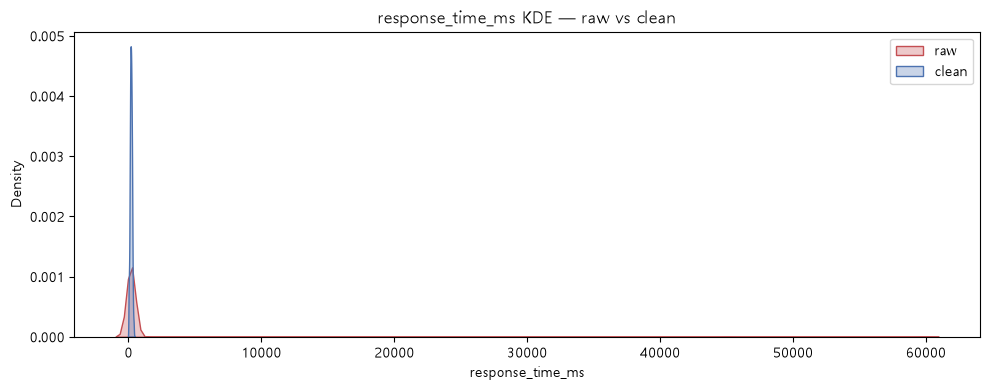

In [34]:
# ===== 여기에 원하는 컬럼명만 넣으시면 됩니다 =====
COLUMN = "response_time_ms"
# ================================================

raw_data = logs_raw[COLUMN].dropna()
clean_data = logs_raw_clean[COLUMN].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(raw_data, label="raw", color="#C44E52", fill=True, alpha=0.3, ax=ax)
sns.kdeplot(clean_data, label="clean", color="#4C72B0", fill=True, alpha=0.3, ax=ax)
ax.set_title(f"{COLUMN} KDE — raw vs clean")
ax.set_xlabel(COLUMN)
ax.legend()
plt.tight_layout()
plt.show()

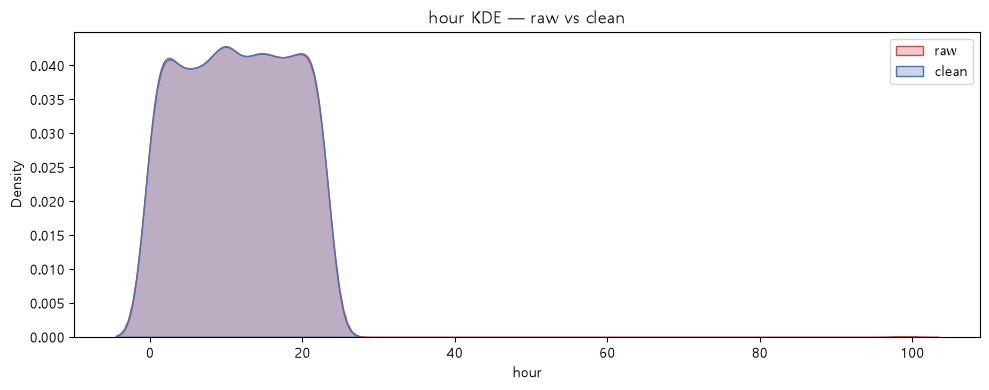

In [35]:
# ===== 여기에 원하는 컬럼명만 넣으시면 됩니다 =====
COLUMN = "hour"
# ================================================

raw_data = logs_raw[COLUMN].dropna()
clean_data = logs_raw_clean[COLUMN].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(raw_data, label="raw", color="#C44E52", fill=True, alpha=0.3, ax=ax)
sns.kdeplot(clean_data, label="clean", color="#4C72B0", fill=True, alpha=0.3, ax=ax)
ax.set_title(f"{COLUMN} KDE — raw vs clean")
ax.set_xlabel(COLUMN)
ax.legend()
plt.tight_layout()
plt.show()

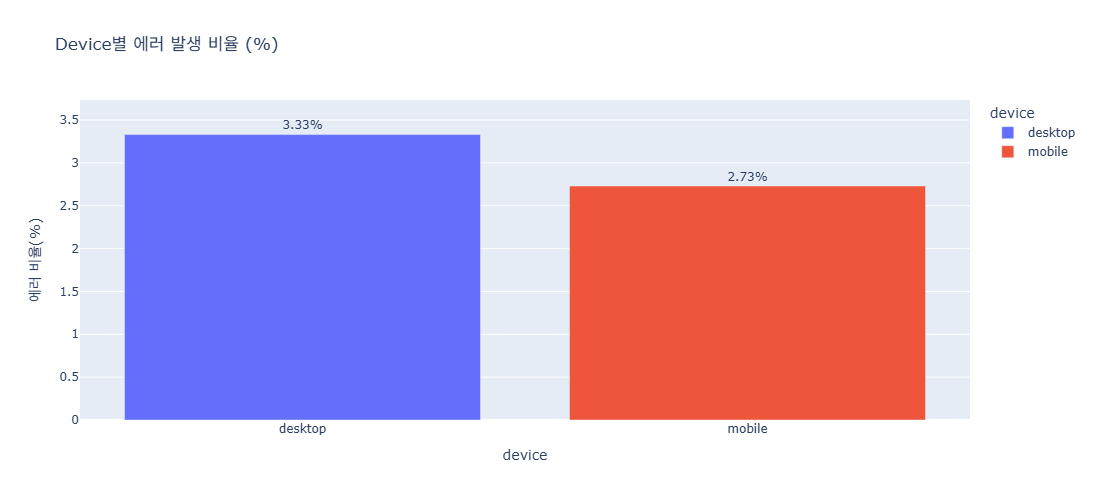

In [38]:
error_rate = (logs_raw_clean.groupby("device")["is_error"].mean() * 100).round(2).reset_index()
error_rate.columns = ["device", "error_rate_pct"]

fig = px.bar(
    error_rate, x="device", y="error_rate_pct",
    color="device",
    text="error_rate_pct",
    title="Device별 에러 발생 비율 (%)",
    labels={"error_rate_pct": "에러 비율(%)"}
)
fig.update_traces(texttemplate="%{text}%", textposition="outside")
fig.update_layout(width=800, height=500)
fig.show()

In [ ]:
missing_by_session.max()

<Axes: xlabel='response_time_ms', ylabel='Count'>

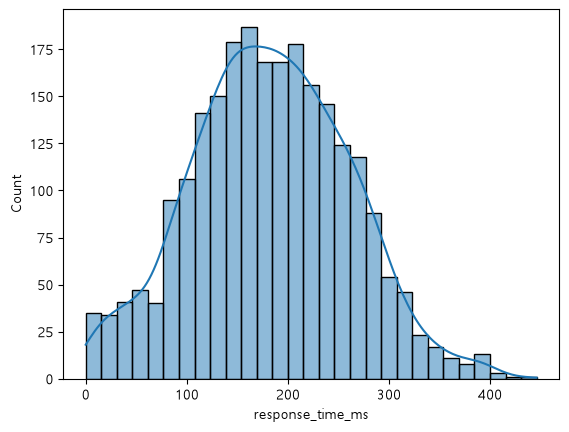

In [40]:
sns.histplot(logs_raw_clean["response_time_ms"], kde=True)

<Axes: xlabel='device', ylabel='response_time_ms'>

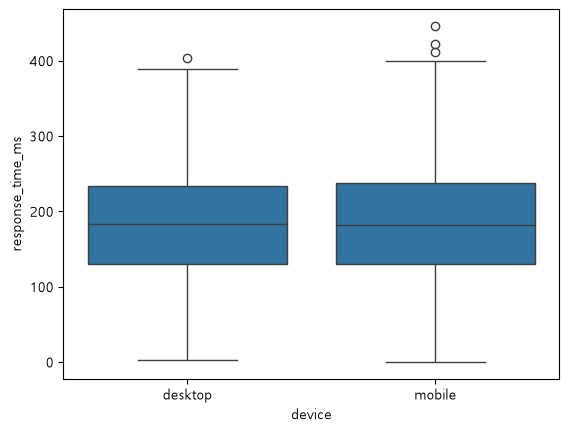

In [41]:
sns.boxplot(data=logs_raw_clean, x="device", y="response_time_ms")

<Axes: xlabel='request_path'>

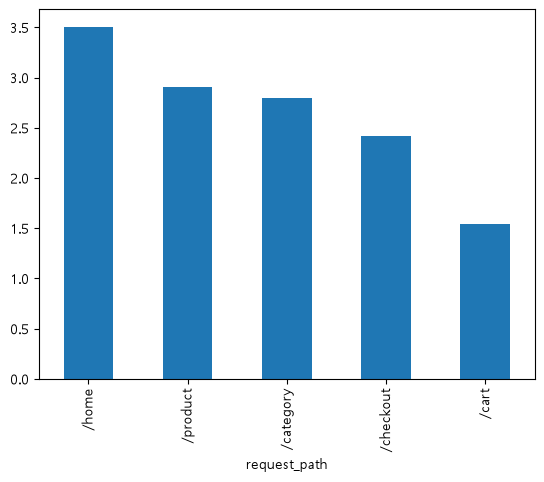

In [42]:
error_by_path = logs_raw_clean.groupby("request_path")["is_error"].mean().sort_values(ascending=False) * 100
error_by_path.plot(kind="bar")

<Axes: xlabel='hour'>

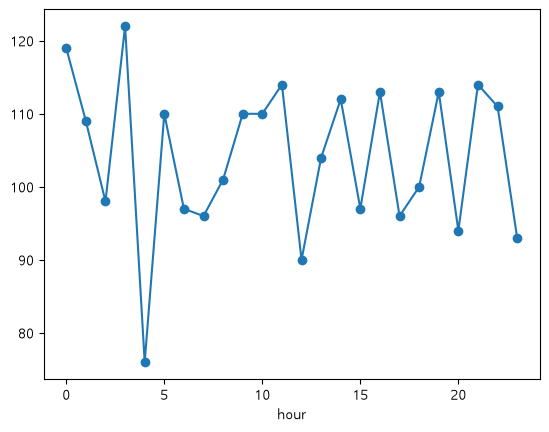

In [43]:
logs_raw_clean.groupby("hour").size().plot(kind="line", marker="o")

<Axes: xlabel='hour'>

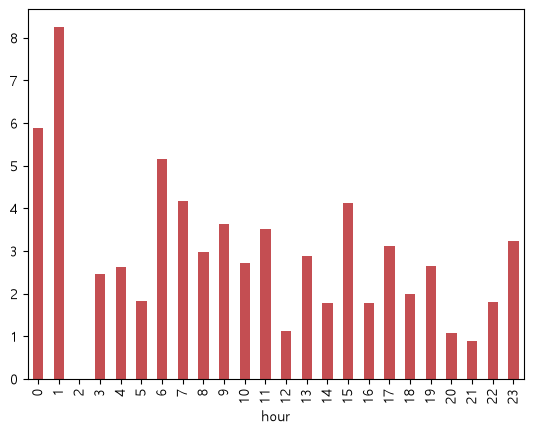

In [44]:
error_by_hour = logs_raw_clean.groupby("hour")["is_error"].mean() * 100
error_by_hour.plot(kind="bar", color="#C44E52")

<Axes: xlabel='is_error', ylabel='response_time_ms'>

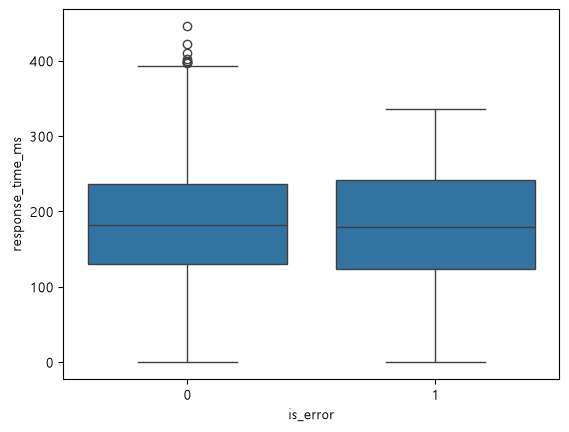

In [45]:
sns.boxplot(data=logs_raw_clean, x="is_error", y="response_time_ms")

<Axes: xlabel='device', ylabel='hour'>

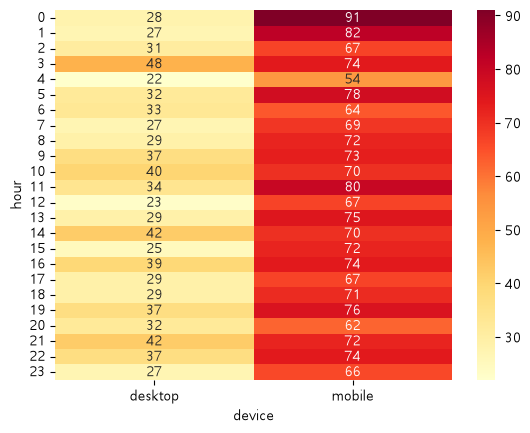

In [46]:
pivot = logs_raw_clean.pivot_table(index="hour", columns="device", values="log_id", aggfunc="count")
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt="d")

<Axes: ylabel='Count'>

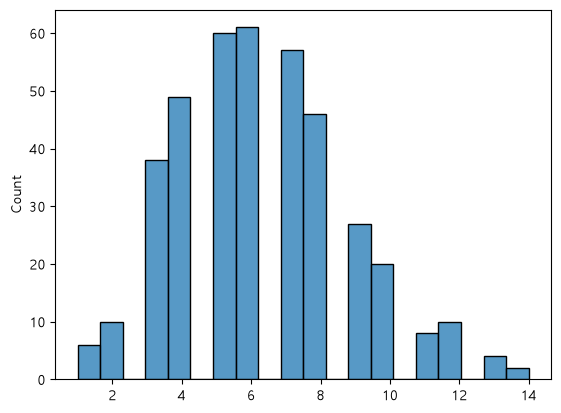

In [47]:
session_counts = logs_raw_clean.groupby("session_id").size()
sns.histplot(session_counts, bins=20)

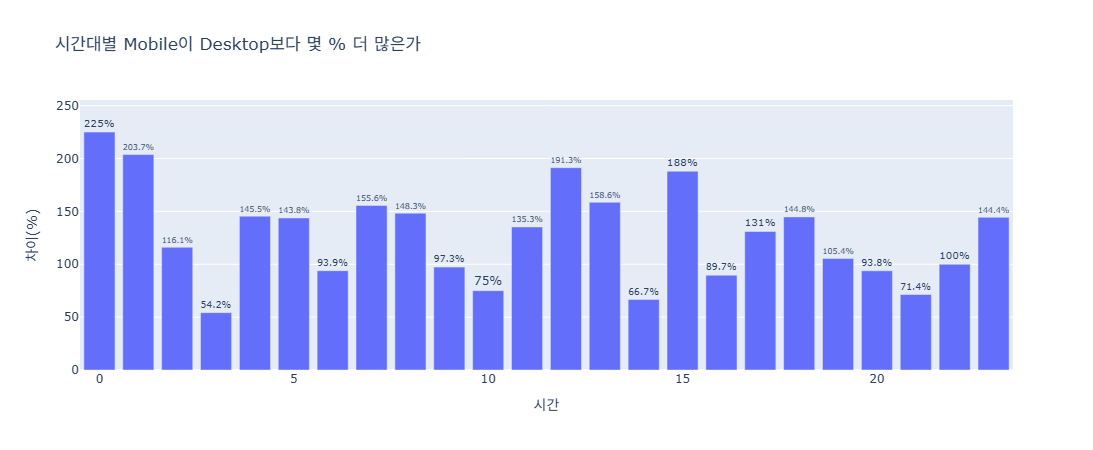

In [49]:
pivot = logs_raw_clean.pivot_table(index="hour", columns="device", values="log_id", aggfunc="count")
pivot["mobile_vs_desktop_%"] = ((pivot["mobile"] - pivot["desktop"]) / pivot["desktop"] * 100).round(1)
pivot = pivot.reset_index()

fig = px.bar(
    pivot, x="hour", y="mobile_vs_desktop_%",
    text="mobile_vs_desktop_%",
    title="시간대별 Mobile이 Desktop보다 몇 % 더 많은가",
    labels={"mobile_vs_desktop_%": "차이(%)", "hour": "시간"},
    hover_data={"desktop": True, "mobile": True}   # 마우스 올리면 원본 건수도 같이 보임
)
fig.update_traces(texttemplate="%{text}%", textposition="outside")
fig.update_layout(width=900, height=450)
fig.show()